# 02 DDSR Comparative Results

Uses all 520k attached records to compare QKD-only, PQC-only, static hybrid, and SEQACS DDSR.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
cols=["ddsr_qkd_only","ddsr_pqc_only","ddsr_static_hybrid","ddsr_seqacs"]
summary=df[cols].agg(["mean","std","median","min","max"]).T
summary.to_csv(OUT/"ddsr_overall_summary.csv"); display(summary)

,mean,std,median,min,max
ddsr_qkd_only,0.230152,0.150207,0.15968,0.07382,0.56515
ddsr_pqc_only,0.242196,0.055956,0.23961,0.08157,0.40394
ddsr_static_hybrid,0.213153,0.036093,0.22036,0.10576,0.31974
ddsr_seqacs,0.159629,0.050559,0.15258,0.06524,0.56733


,ddsr_qkd_only,ddsr_pqc_only,ddsr_static_hybrid,ddsr_seqacs
scenario,,,,
S1_Normal,0.129319,0.171337,0.161813,0.106094
S2_Quantum_Eavesdropping,0.228559,0.234184,0.232723,0.181553
S3_Harvest_Now_Decrypt_Later,0.156316,0.225744,0.186423,0.125721
S4_QKD_Link_Failure,0.431434,0.232071,0.233741,0.208765
S5_PQC_Computational_Overload,0.191124,0.308865,0.222833,0.151580
S6_Hybrid_Adversarial_Attack,0.268995,0.299209,0.254366,0.197446


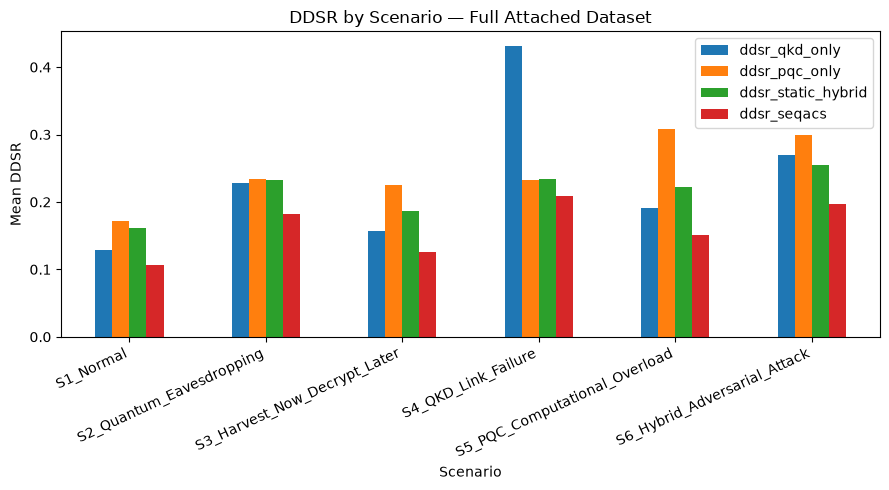

In [3]:
sc=df.groupby("scenario")[cols].mean(); sc.to_csv(OUT/"ddsr_by_scenario.csv"); display(sc)
plt.figure(figsize=(9,5)); sc.plot(kind="bar",ax=plt.gca())
plt.ylabel("Mean DDSR"); plt.xlabel("Scenario"); plt.title("DDSR by Scenario — Full Attached Dataset")
plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.savefig(OUT/"fig_ddsr_by_scenario.png",dpi=300); plt.show()